Dataset shape: (4262, 26)
Date range:    2014-10-17 → 2026-06-18

--- Phase 1: EDA ---


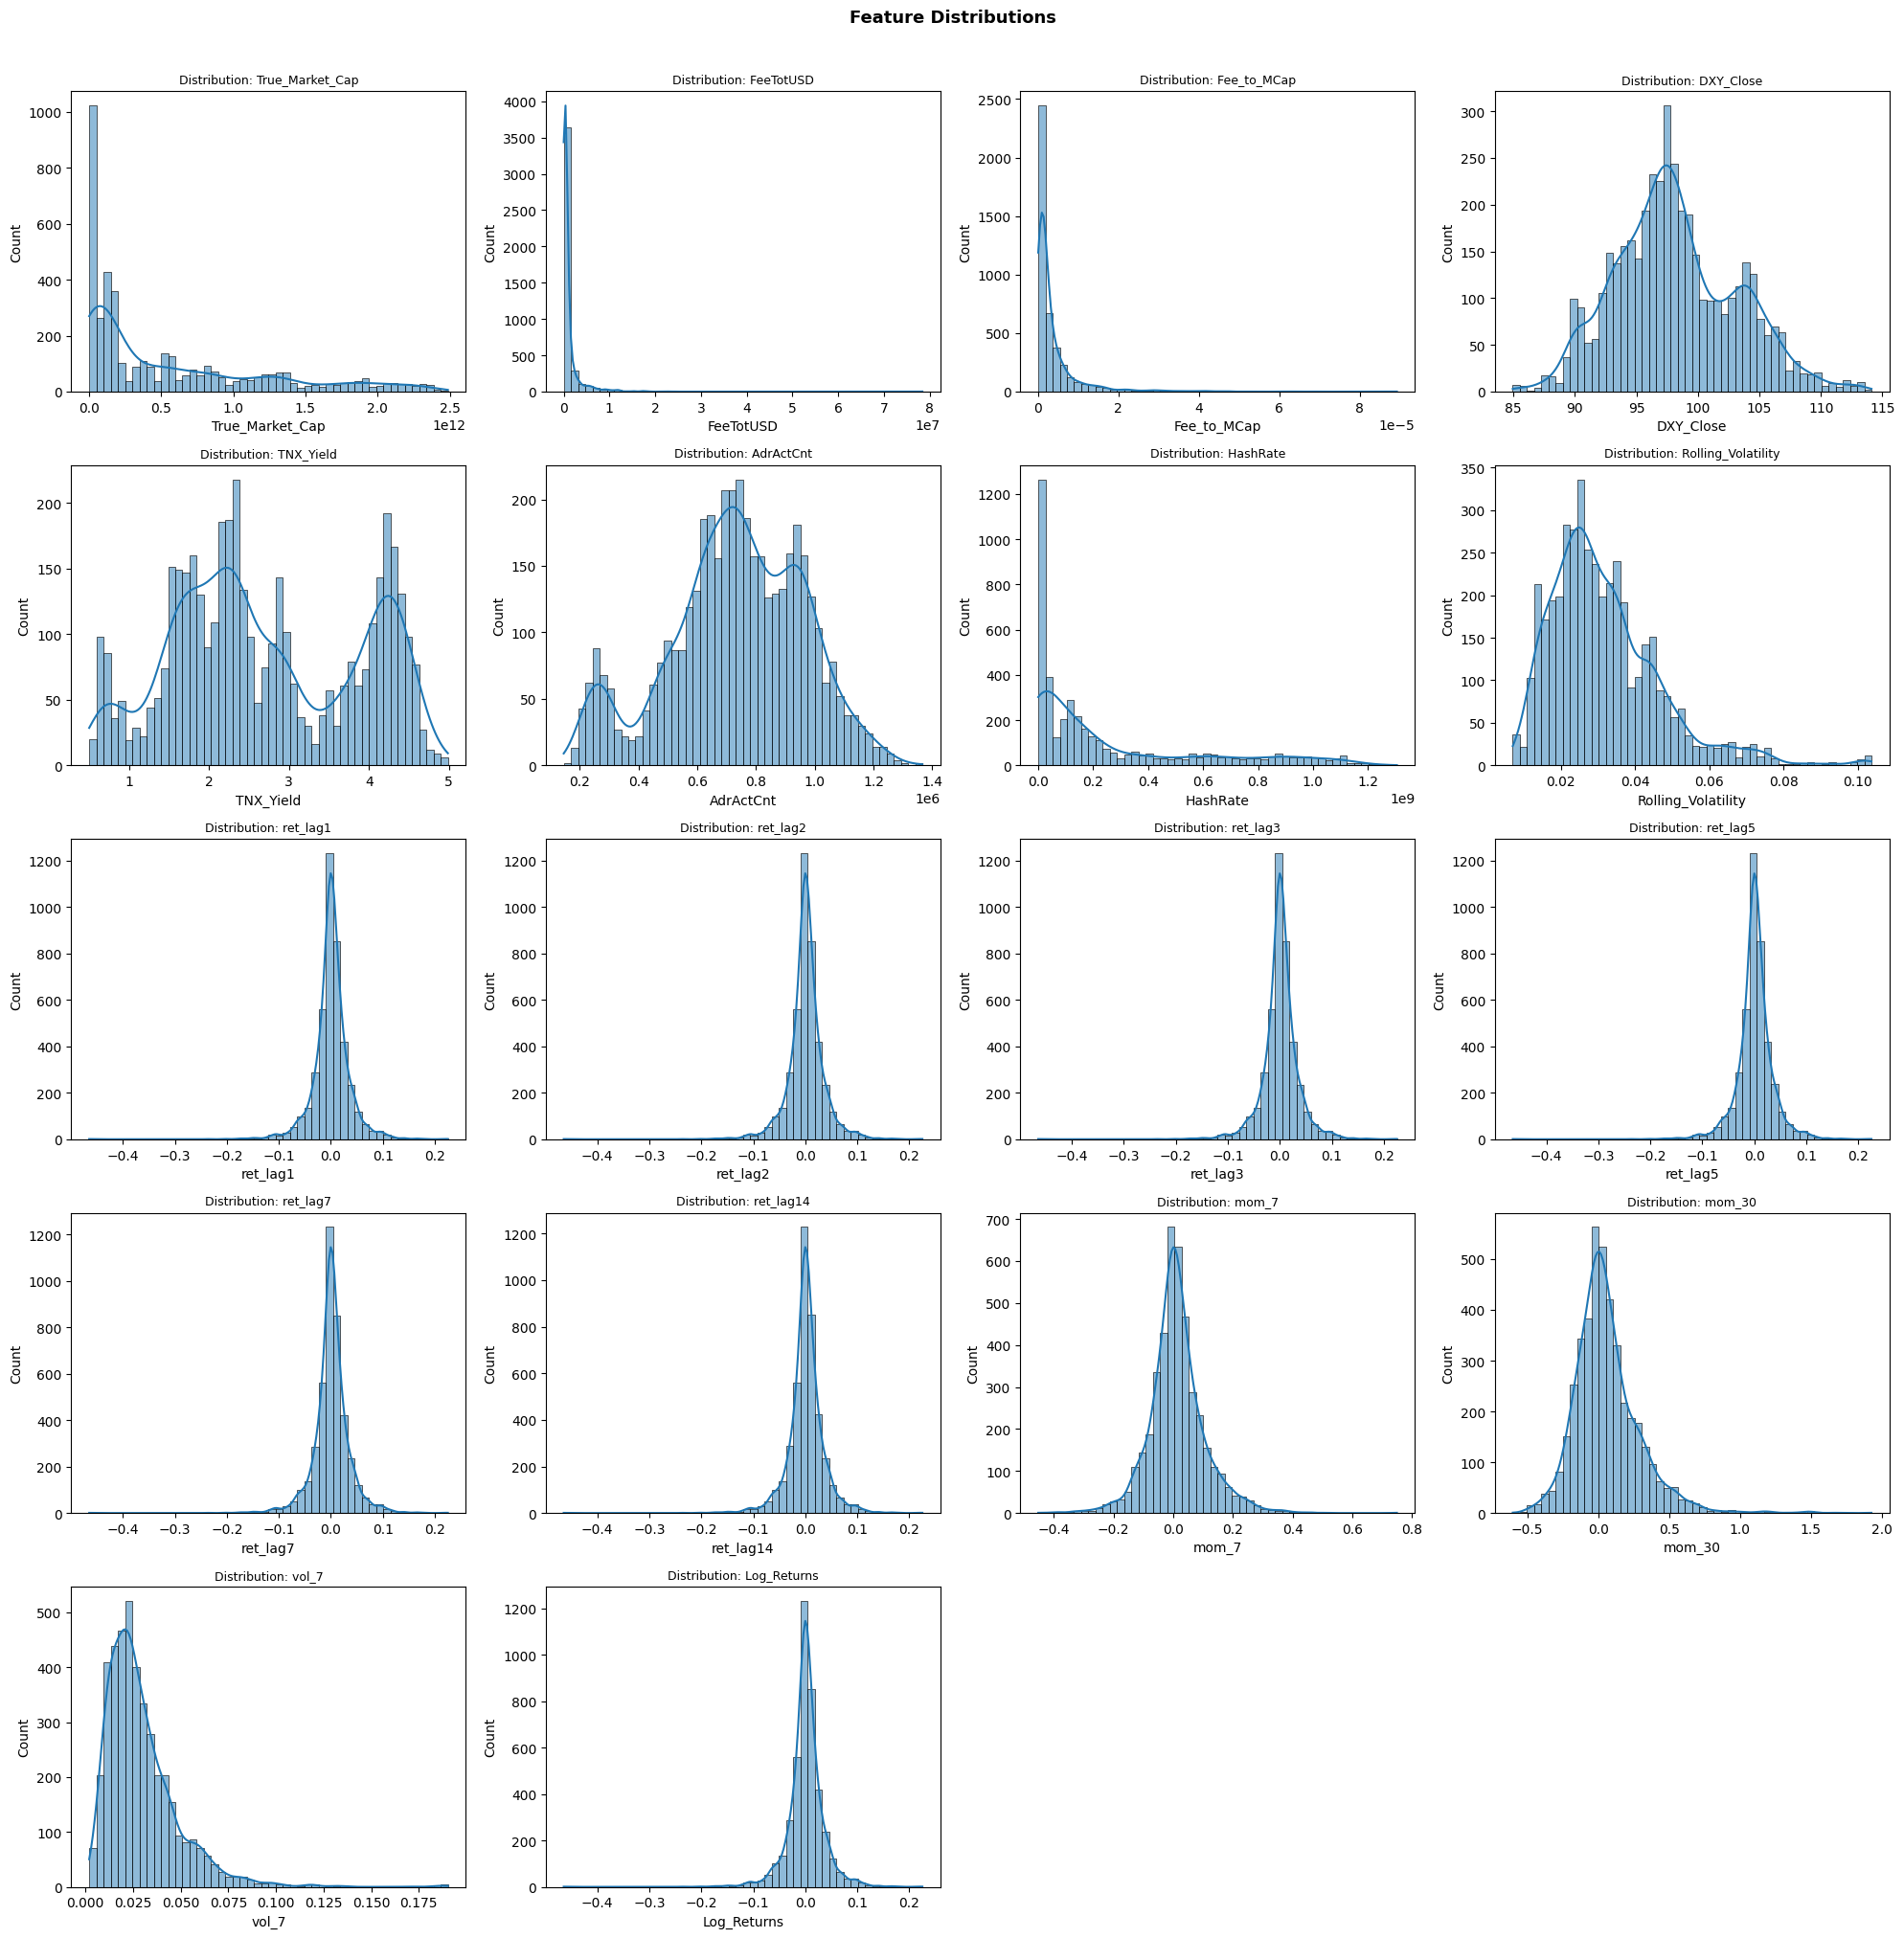

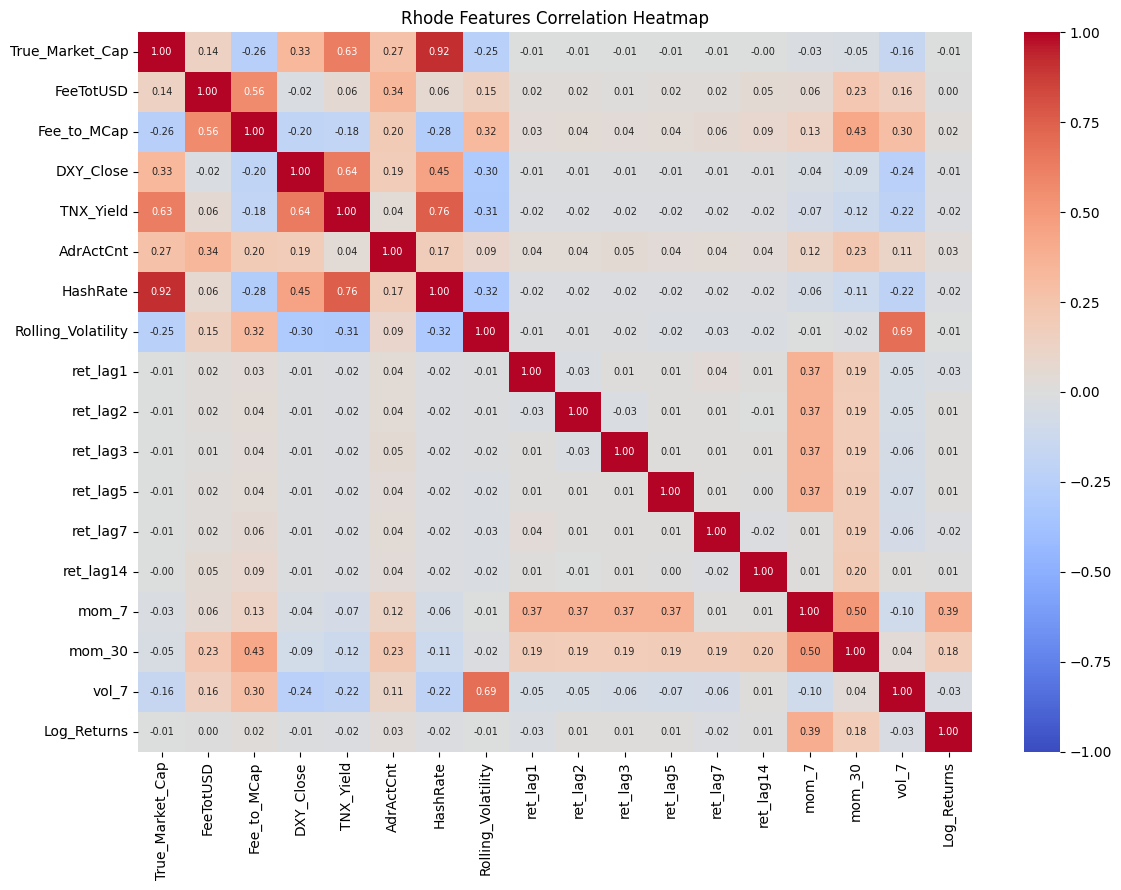


Stationarity Check (ADF Test p-values):
  True_Market_Cap         : p = 0.6458  (Non-Stationary)
  FeeTotUSD               : p = 0.0000  (Stationary)
  Fee_to_MCap             : p = 0.0000  (Stationary)
  DXY_Close               : p = 0.0272  (Stationary)
  TNX_Yield               : p = 0.8371  (Non-Stationary)
  AdrActCnt               : p = 0.0951  (Non-Stationary)
  HashRate                : p = 0.9991  (Non-Stationary)
  Rolling_Volatility      : p = 0.0001  (Stationary)
  ret_lag1                : p = 0.0000  (Stationary)
  ret_lag2                : p = 0.0000  (Stationary)
  ret_lag3                : p = 0.0000  (Stationary)
  ret_lag5                : p = 0.0000  (Stationary)
  ret_lag7                : p = 0.0000  (Stationary)
  ret_lag14               : p = 0.0000  (Stationary)
  mom_7                   : p = 0.0000  (Stationary)
  mom_30                  : p = 0.0000  (Stationary)
  vol_7                   : p = 0.0000  (Stationary)
  Log_Returns             : p = 0.0000  (S

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, accuracy_score
)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import adfuller
# ══════════════════════════════════════════════════════════════════════
# 0. LOAD DATA & FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════

df = pd.read_csv('btc_alpha_master_2014_2026 (1).csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

df['Log_Returns']        = np.log(df['Close'] / df['Close'].shift(1))
df['Rolling_Volatility'] = df['Log_Returns'].rolling(window=30).std()

for lag in [1, 2, 3, 5, 7, 14]:
    df[f'ret_lag{lag}'] = df['Log_Returns'].shift(lag)

df['mom_7']  = df['Close'].pct_change(7)
df['mom_30'] = df['Close'].pct_change(30)
df['vol_7']  = df['Log_Returns'].rolling(7).std()

df.dropna(subset=['Log_Returns', 'Rolling_Volatility'], inplace=True)

rhode_features = [
    'True_Market_Cap', 'FeeTotUSD', 'Fee_to_MCap',
    'DXY_Close', 'TNX_Yield', 'AdrActCnt', 'HashRate', 'Rolling_Volatility',
    'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag7', 'ret_lag14',
    'mom_7', 'mom_30', 'vol_7',
]
target = 'Log_Returns'

print(f'Dataset shape: {df.shape}')
print(f'Date range:    {df.index.min().date()} → {df.index.max().date()}')
# ══════════════════════════════════════════════════════════════════════
# 1. EDA
# ══════════════════════════════════════════════════════════════════════
print('\n--- Phase 1: EDA ---')

# 1a. Distributions
all_cols = rhode_features + [target]
n_cols   = 4
n_rows   = (len(all_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes_flat = axes.flatten()

for i, col in enumerate(all_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=50, ax=axes_flat[i])
    axes_flat[i].set_title(f'Distribution: {col}', fontsize=9)

for j in range(len(all_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Feature Distributions', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 1b. Correlation Heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df[rhode_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Rhode Features Correlation Heatmap')
plt.tight_layout()
plt.show()

# 1c. Stationarity — ADF Test
print('\nStationarity Check (ADF Test p-values):')
for col in rhode_features + [target]:
    series = df[col].dropna()
    p_val  = adfuller(series)[1]
    label  = 'Stationary' if p_val < 0.05 else 'Non-Stationary'
    print(f'  {col:<24}: p = {p_val:.4f}  ({label})')
    # ══════════════════════════════════════════════════════════════════════
# 2. DATA PREPARATION
# ══════════════════════════════════════════════════════════════════════
print('\n--- Phase 2: Data Preparation ---')

model_df = df[rhode_features + [target]].copy()
model_df.ffill(inplace=True)
model_df.dropna(inplace=True)

n         = len(model_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = model_df.iloc[:train_end]
val_df   = model_df.iloc[train_end:val_end]
test_df  = model_df.iloc[val_end:]

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_df[rhode_features])
y_train = train_df[target].values

X_val   = scaler.transform(val_df[rhode_features])
y_val   = val_df[target].values

X_test  = scaler.transform(test_df[rhode_features])
y_test  = test_df[target].values
# ══════════════════════════════════════════════════════════════════════
# 3. ML MODELS
# ══════════════════════════════════════════════════════════════════════
print('\n--- Phase 3: Model Implementation ---')

# Model 1: Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('Random Forest trained.')

# Model 2: XGBoost
# early_stopping_rounds removed → caused ghost trees that zero out importances
# gamma=0 / reg_alpha=0 → removed penalties that starved weak features
# colsample_bytree=0.8  → ensures every feature participates across trees
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    colsample_bylevel=0.8,
    min_child_weight=1,
    gamma=0.0,
    reg_alpha=0.0,
    reg_lambda=0.5,
    random_state=42,
)
xgb_model.fit(X_train, y_train, verbose=False)
print('XGBoost trained.')

predictions = xgb_model.predict(X_test)

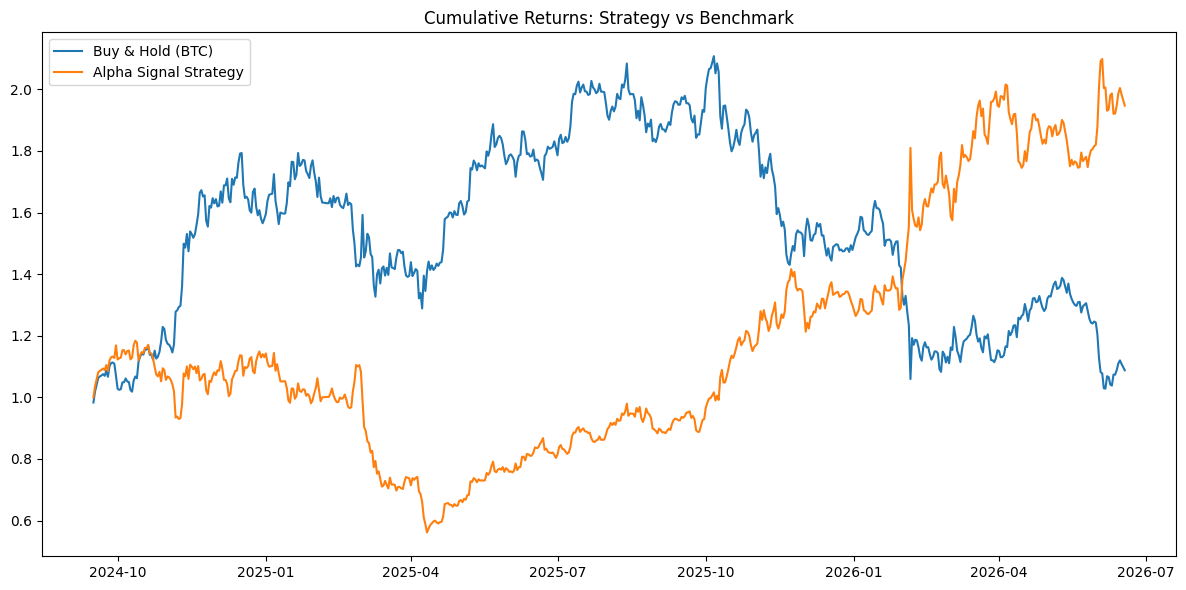

In [13]:
# ══════════════════════════════════════════════════════════════════════
# 4. ALPHA SIGNAL GENERATION & STRATEGY SIMULATION
# ══════════════════════════════════════════════════════════════════════

# Long (+1) when predicted return > 0, Short (-1) otherwise
signals = np.where(predictions > 0, 1, -1)

# Shift by 1: predict at t, trade at t+1 → avoids look-ahead bias
trading_signals  = pd.Series(signals).shift(1).fillna(0).values
strategy_returns = trading_signals * y_test

results_df = pd.DataFrame({
    'Benchmark_Return': y_test,
    'Strategy_Return':  strategy_returns,
}, index=test_df.index)

results_df['Cum_Benchmark'] = np.exp(results_df['Benchmark_Return'].cumsum())
results_df['Cum_Strategy']  = np.exp(results_df['Strategy_Return'].cumsum())

plt.figure(figsize=(12, 6))
plt.plot(results_df.index, results_df['Cum_Benchmark'],
         label='Buy & Hold (BTC)', lw=1.5)
plt.plot(results_df.index, results_df['Cum_Strategy'],
         label='Alpha Signal Strategy', lw=1.5)
plt.title('Cumulative Returns: Strategy vs Benchmark')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ══════════════════════════════════════════════════════════════════════
# 5. EVALUATION
# ══════════════════════════════════════════════════════════════════════
print('\n--- Phase 5: Evaluation ---')

mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

# np.sign(0.0)==0 creates a 3rd class → use np.where for strict binary labels
y_dir   = np.where(y_test      > 0, 1, -1)
p_dir   = np.where(predictions > 0, 1, -1)
dir_acc = accuracy_score(y_dir, p_dir)

print(f'  MAE:                  {mae:.6f}')
print(f'  RMSE:                 {rmse:.6f}')
print(f'  R²:                   {r2:.6f}')
print(f'  Directional Accuracy: {dir_acc * 100:.2f}%')


def calc_sharpe(returns, risk_free_rate=0.0):
    excess = returns - risk_free_rate / 365
    return np.sqrt(365) * (excess.mean() / excess.std())

def calc_max_drawdown(cum_returns):
    return (cum_returns / cum_returns.cummax() - 1.0).min()


strat_sharpe = calc_sharpe(results_df['Strategy_Return'])
bench_sharpe = calc_sharpe(results_df['Benchmark_Return'])
strat_mdd    = calc_max_drawdown(results_df['Cum_Strategy'])
bench_mdd    = calc_max_drawdown(results_df['Cum_Benchmark'])
strat_ret    = results_df['Cum_Strategy'].iloc[-1]  - 1
bench_ret    = results_df['Cum_Benchmark'].iloc[-1] - 1

print('\nFinancial Metrics:')
print(f'  Strategy Sharpe:        {strat_sharpe:.2f}   (Bench: {bench_sharpe:.2f})')
print(f'  Strategy Max Drawdown:  {strat_mdd*100:.2f}%  (Bench: {bench_mdd*100:.2f}%)')
print(f'  Strategy Cum. Return:   {strat_ret*100:.2f}%  (Bench: {bench_ret*100:.2f}%)')


--- Phase 5: Evaluation ---
  MAE:                  0.014259
  RMSE:                 0.019336
  R²:                   0.337284
  Directional Accuracy: 66.41%

Financial Metrics:
  Strategy Sharpe:        0.84   (Bench: 0.11)
  Strategy Max Drawdown:  -52.58%  (Bench: -51.21%)
  Strategy Cum. Return:   94.72%  (Bench: 8.81%)



--- Phase 6: Feature Importance ---


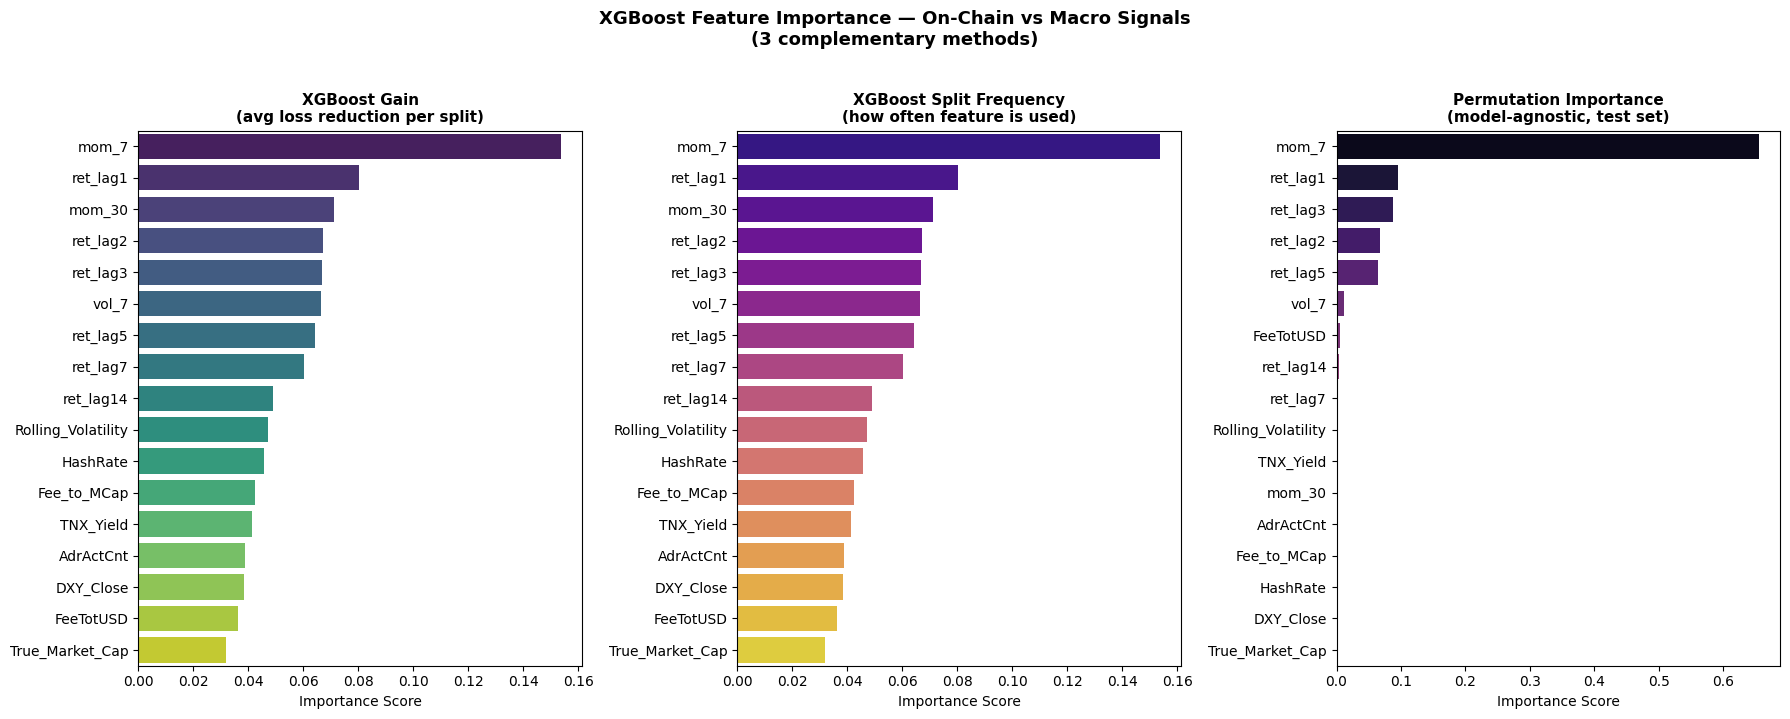


Feature                      Gain   Split Freq   Permutation
------------------------------------------------------------
  mom_7                    0.1536       0.1536        0.6555
  ret_lag1                 0.0801       0.0801        0.0961
  mom_30                   0.0712       0.0712        0.0008
  ret_lag2                 0.0671       0.0671        0.0682
  ret_lag3                 0.0669       0.0669        0.0877
  vol_7                    0.0663       0.0663        0.0111
  ret_lag5                 0.0641       0.0641        0.0636
  ret_lag7                 0.0602       0.0602        0.0025
  ret_lag14                0.0490       0.0490        0.0041
  Rolling_Volatility       0.0470       0.0470        0.0022
  HashRate                 0.0456       0.0456        0.0000
  Fee_to_MCap              0.0424       0.0424        0.0004
  TNX_Yield                0.0413       0.0413        0.0017
  AdrActCnt                0.0388       0.0388        0.0008
  DXY_Close            

In [15]:
# ══════════════════════════════════════════════════════════════════════
# 6. FEATURE IMPORTANCE  (3 complementary methods)
# ══════════════════════════════════════════════════════════════════════
print('\n--- Phase 6: Feature Importance ---')

# Method A: XGBoost gain importance
booster     = xgb_model.get_booster()
gain_scores = booster.get_score(importance_type='gain')

# Internal names f0/f1/... must be mapped back to real feature names
feat_map    = {f'f{i}': name for i, name in enumerate(rhode_features)}
gain_named  = {feat_map.get(k, k): v for k, v in gain_scores.items()}
gain_series = pd.Series({f: gain_named.get(f, 0.0) for f in rhode_features})
gain_series = gain_series / gain_series.sum()

# Method B: XGBoost split frequency
xgb_importance = pd.Series(xgb_model.feature_importances_, index=rhode_features)

# Method C: Permutation importance (model-agnostic, most reliable)
perm = permutation_importance(
    xgb_model, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1
)
perm_series = pd.Series(np.maximum(perm.importances_mean, 0), index=rhode_features)
perm_norm   = perm_series / perm_series.sum() if perm_series.sum() > 0 else perm_series

importance_df = pd.DataFrame({
    'XGB_Gain':       gain_series,
    'XGB_Split_Freq': xgb_importance,
    'Permutation':    perm_norm,
}).sort_values('XGB_Gain', ascending=False)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
titles   = ['XGBoost Gain\n(avg loss reduction per split)',
             'XGBoost Split Frequency\n(how often feature is used)',
             'Permutation Importance\n(model-agnostic, test set)']
cols     = ['XGB_Gain', 'XGB_Split_Freq', 'Permutation']
palettes = ['viridis', 'plasma', 'magma']

for ax, col, title, pal in zip(axes, cols, titles, palettes):
    data = importance_df.sort_values(col, ascending=False)
    sns.barplot(x=col, y=data.index, data=data, palette=pal, ax=ax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('')

fig.suptitle('XGBoost Feature Importance — On-Chain vs Macro Signals\n'
             '(3 complementary methods)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ranking table
print(f"\n{'Feature':<22} {'Gain':>10} {'Split Freq':>12} {'Permutation':>13}")
print('-' * 60)
for feat in importance_df.index:
    print(f"  {feat:<20} "
          f"{importance_df.loc[feat,'XGB_Gain']:>10.4f} "
          f"{importance_df.loc[feat,'XGB_Split_Freq']:>12.4f} "
          f"{importance_df.loc[feat,'Permutation']:>13.4f}")